# Proyecto Series Temporales


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Cargamos los datos
df_train = pd.read_parquet("ts-train.parquet")
df_test = pd.read_parquet("ts-test.parquet")

In [3]:
df_train.head()

,mw,temp,hora,dia,diasemana,mes,anyo
fecha,,,,,,,
2017-02-01 00:53:00,1419.881,37.0,0,1,2,2,2017
2017-02-01 01:53:00,1379.505,37.0,1,1,2,2,2017
2017-02-01 02:53:00,1366.106,36.0,2,1,2,2,2017
2017-02-01 03:53:00,1364.453,36.0,3,1,2,2,2017
2017-02-01 04:53:00,1391.265,36.0,4,1,2,2,2017


## 6. Construyendo el modelo

Vamos a añadir un módulo adicional llamado ``statsmodels``. Necesitamos construir modelos de regresión en este hito y para ello lo necesitaremos. Es un módulo de Python que proporciona clases y funciones para la estimación de muchos modelos estadísticos diferentes, así como para la realización de pruebas estadísticas, y la exploración de datos estadísticos.

¡Este hito se basa en los anteriores, por lo que debemos completar los siguientes pasos para el primer hito de nuevo para tener nuestros datos preparados y listos para ir!

In [11]:
!pip install statsmodels --upgrade

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 9.6/9.6 MB 55.7 MB/s eta 0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.4
    Uninstalling statsmodels-0.14.4:
      Successfully uninstalled statsmodels-0.14.4



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.graphics import tsaplots

El paquete statsmodels tiene una función `OLS` y una función `OLS.from_formula` para ayudar a construir modelos de regresión lineal.

* La función `OLS` requiere la variable objetivo y las variables predictoras como entradas separadas `y` y `X` respectivamente. Para una regresión lineal en la que sólo la temperatura predice la energía, tendríamos `sm.OLS(train['MW'], train['Temp']).fit()`.
* La función `OLS.from_formula` adopta un enfoque más basado en fórmulas para definir un modelo. Para construir la misma regresión lineal con sólo la temperatura prediciendo la energía tendríamos `sm.OLS.from_formula('MW ~ Temp', data=train).fit()`

En primer lugar, repasemos algunos de los resultados de las dos primeras etapas:
- El consumo de energía varía en función del mes o la estación
- El consumo de energía varía en función del día de la semana.
- El consumo de energía varía en función de la hora del día
- El consumo de energía varía en función de la temperatura exterior
- La relación entre la temperatura y el consumo de energía parece cuadrática.

Teniendo en cuenta este último punto, necesitamos crear una variable cuadrática sobre la temperatura, ya que la temperatura en el modelo por sí sola no será suficiente para modelar el consumo de energía. Siempre es una buena práctica estandarizar (media de 0 y desviación estándar de 1) cualquier variable que se vaya a elevar a una potencia superior en una regresión para ayudar a evitar problemas de multicolinealidad. Podemos estandarizar la variable *Temp* utilizando las funciones `mean` y `std`.

In [14]:
df_train['temp_norm'] = (df_train['temp']-df_train['temp'].mean())/df_train['temp'].std()

Ahora que la temperatura está estandarizada (o normalizada) podemos multiplicarla por sí misma para obtener nuestro término cuadrático.

In [15]:
df_train['temp_norm2'] = df_train['temp_norm']**2

In [16]:
df_train.head()

,mw,temp,hora,dia,diasemana,mes,anyo,temp_norm,temp_norm2
fecha,,,,,,,,,
2017-02-01 00:53:00,1419.881,37.0,0,1,2,2,2017,-0.871499,0.759511
2017-02-01 01:53:00,1379.505,37.0,1,1,2,2,2017,-0.871499,0.759511
2017-02-01 02:53:00,1366.106,36.0,2,1,2,2,2017,-0.924494,0.854690
2017-02-01 03:53:00,1364.453,36.0,3,1,2,2,2017,-0.924494,0.854690
2017-02-01 04:53:00,1391.265,36.0,4,1,2,2,2017,-0.924494,0.854690


Estupendo. Ahora tenemos la base para construir un modelo. 

El modelo energético ingenuo no es más que un modelo de regresión lineal. Utilizará los términos que ya hemos identificado como potencialmente impactantes en el uso de la energía: hora del día, día de la semana, mes del año, temperatura y el término cuadrático de la temperatura (*ordinary least squares (OLS)*). La función `OLS.from_formula` del módulo `statsmodels` se encargará de ello. A continuación, podemos utilizar la función `summary` para ver nuestros resultados.

In [17]:
results = sm.OLS.from_formula('mw ~ temp_norm + temp_norm2 + C(diasemana) + C(hora) + C(mes)', data=df_train).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                     mw   R-squared:                       0.840
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     3180.
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        18:37:42   Log-Likelihood:            -1.5735e+05
No. Observations:               25536   AIC:                         3.148e+05
Df Residuals:                   25493   BIC:                         3.151e+05
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1272.0274      5.42

De lo anterior se desprende que todas las variables parecen estar estadísticamente relacionadas con la energía. Nuestro modelo ha tenido un buen comienzo. Intentemos añadir términos adicionales a nuestro modelo para mejorarlo.

Ya hemos comprobado si el mes y la temperatura influyen por separado en el consumo de energía. Sin embargo, a partir de los gráficos que vimos antes, también planteamos la hipótesis de que el efecto de la temperatura era diferente en los distintos meses. Intentemos visualizarlo aquí. El siguiente código resalta los meses de enero y julio en nuestro anterior gráfico de dispersión de temperatura por consumo de energía.

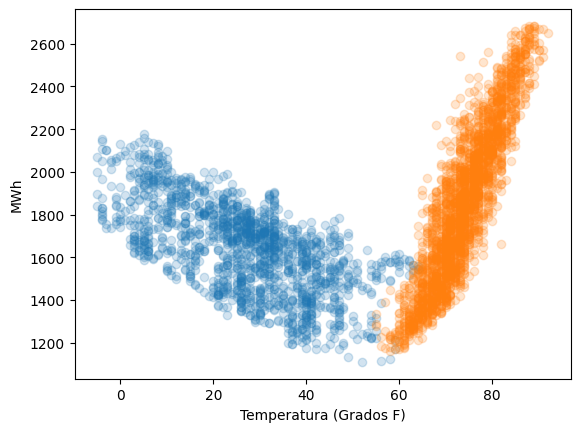

In [19]:
plt.subplot()
plt.scatter(df_train['temp'].where(df_train['mes'] == 1), df_train['mw'].where(df_train['mes'] == 1), alpha = 0.2)
plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')

plt.subplot()
plt.scatter(df_train['temp'].where(df_train['mes'] == 7), df_train['mw'].where(df_train['mes'] == 7), alpha = 0.2)
plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')

plt.show()

¿Qué nos muestra esto? Muestra exactamente lo que vimos en el hito 2. Parece que en julio la temperatura tiene una relación diferente con la energía que en enero. Esta relación diferente se llama interacción. Por suerte, se pueden añadir fácilmente a los modelos. Comprobemos si existe el mismo fenómeno en diferentes horas. A continuación destacamos las horas de medianoche y mediodía para nuestro gráfico de dispersión de temperatura por energía.

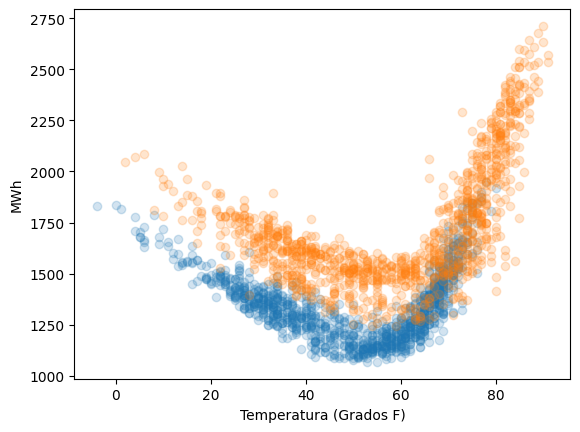

In [23]:
plt.subplot()
plt.scatter(df_train['temp'].where(df_train['hora'] == 0), df_train['mw'].where(df_train['hora'] == 0), alpha = 0.2)
plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')

plt.subplot()
plt.scatter(df_train['temp'].where(df_train['hora'] == 12), df_train['mw'].where(df_train['hora'] == 12), alpha = 0.2)
plt.xlabel('Temperatura (Grados F)')
plt.ylabel('MWh')

plt.show()